# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data.csv` file you exported from Assignment 6.

📌 In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
try:
    df = pd.read_csv('cleaned_airbnb_data.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: cleaned_airbnb_data.csv not found. Please upload the file.")

Dataset loaded successfully!


## 2. Check for Skew in a Numeric Column

Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare


### In Your Response:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?



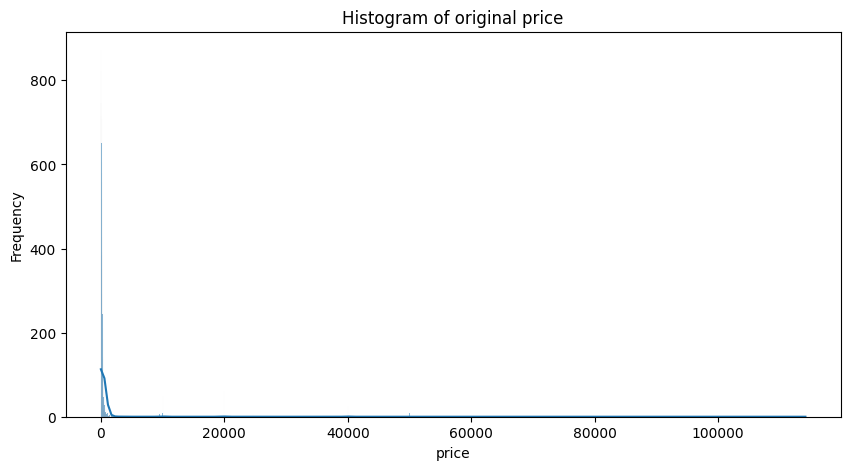

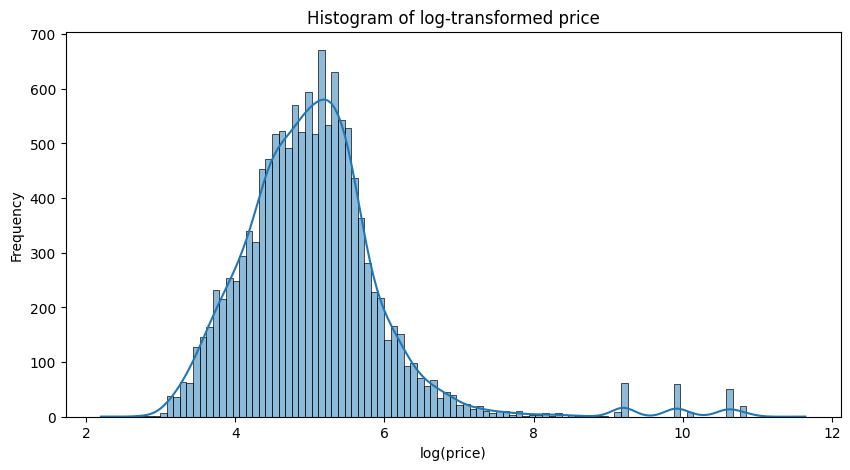

In [2]:
# Choose a numeric column to examine for skew (e.g., 'price')
column_to_examine = 'price'

# Plot a histogram of the original data
plt.figure(figsize=(10, 5))
sns.histplot(df[column_to_examine], kde=True)
plt.title(f'Histogram of original {column_to_examine}')
plt.xlabel(column_to_examine)
plt.ylabel('Frequency')
plt.show()

# Apply a log transformation
# Add a small constant to avoid log(0) if necessary
df['price_log_transformed'] = np.log1p(df[column_to_examine])

# Plot a histogram of the transformed data
plt.figure(figsize=(10, 5))
sns.histplot(df['price_log_transformed'], kde=True)
plt.title(f'Histogram of log-transformed {column_to_examine}')
plt.xlabel(f'log({column_to_examine})')
plt.ylabel('Frequency')
plt.show()

1. I examined the price column.
2. I applied a log transformation using np.log1p(). I chose that because the histogram of the original price data had a strong skew to the right. Log transformations can help make that data more normally distributed, which is more beneficial for analysis.
3. The transformed version helps make the data more usable by reducing the skew and making things more symmetrical. This makes it overall easier to visualize and understand for the stakeholders.

## 3. Scale Two Numeric Columns

Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

Follow these steps:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

### In Your Response:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

In [4]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Choose two numeric columns to scale
column_for_minmax = 'minimum_nights'
column_for_zscore = 'number_of_reviews'

# Handle potential missing values in the chosen columns before scaling
# For simplicity, we'll fill NaNs with 0, but a more sophisticated approach might be needed depending on the data
df[column_for_minmax] = df[column_for_minmax].fillna(0)
df[column_for_zscore] = df[column_for_zscore].fillna(0)


# Min-Max scale on 'minimum_nights'
minmax_scaler = MinMaxScaler()
df[f'{column_for_minmax}_minmax_scaled'] = minmax_scaler.fit_transform(df[[column_for_minmax]])

# Z-score scale on 'number_of_reviews'
zscore_scaler = StandardScaler()
df[f'{column_for_zscore}_zscore_scaled'] = zscore_scaler.fit_transform(df[[column_for_zscore]])

print("Scaled columns added to the DataFrame.")
display(df[[column_for_minmax, f'{column_for_minmax}_minmax_scaled', column_for_zscore, f'{column_for_zscore}_zscore_scaled']].head())

Scaled columns added to the DataFrame.


,minimum_nights,minimum_nights_minmax_scaled,number_of_reviews,number_of_reviews_zscore_scaled
0,7,0.008584,4,-0.421762
1,2,0.001431,203,2.233511
2,2,0.001431,161,1.673101
3,30,0.041488,2,-0.448448
4,29,0.040057,253,2.900664


1. I scaled the minimum_nights column using Min-Max scaling and the number_of_reviews column using Z-score normalization (standardization).
2. Scaled values are more useful than the originals when you need to compare or combine columns with different units or ranges. For example, if you were building a model that uses both minimum nights and number of reviews as features, scaling ensures that neither feature dominates the other simply due to having larger values.
3. Data scientists or analysts at Airbnb would benefit from this transformation. They often use these scaled values when building machine learning models for tasks like predicting listing prices, estimating booking probabilities, or identifying factors that influence success.

## 4. Group a Numeric Column into Categories

Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

Follow these steps:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

### In Your Response:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?


In [5]:
# Choose a numeric column to group (e.g., 'number_of_reviews')
column_to_group = 'number_of_reviews'

# Define the bin edges and labels
# You might need to adjust the bins based on the distribution of your data
bins = [-1, 10, 50, df[column_to_group].max()] # Example bins: <10, 10-50, >50
labels = ['Low', 'Medium', 'High']

# Create the new categorical column
df['review_volume_category'] = pd.cut(df[column_to_group], bins=bins, labels=labels, right=True)

print(f"'{column_to_group}' grouped into review_volume_category.")
display(df[[column_to_group, 'review_volume_category']].head())
display(df['review_volume_category'].value_counts())

'number_of_reviews' grouped into review_volume_category.


,number_of_reviews,review_volume_category
0,4,Low
1,203,High
2,161,High
3,2,Low
4,253,High


,count
review_volume_category,
Low,10384
Medium,3873
High,3634


1. I grouped the 'number_of_reviews' column into three categories: low, medium, and high.
2. Someone might prefer this grouped view over raw numbers because it provides a simpler summary of review activity. Instead of looking at the exact number of reviews for the listing, the stakeholders can quickly understand the general review volume level.
3. The transformation would help roles at Airbnb like the marketing team, they could use the categories to segment listings for different campaigns. The product team could use the categories to analyze listings with the best practices, and the hosts could see their listing categorized, which would help them compare it to other listings.

## 5. Create Two New Business-Relevant Variables

Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

Follow these steps:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

### In Your Response:
1. What two new columns did you create?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

In [6]:
# Create a new column for price per night
# Handle potential division by zero if minimum_nights is 0
df['price_per_night'] = df['price'] / df['minimum_nights'].replace(0, np.nan)

# Create a flag for long stays (e.g., minimum nights > 30)
df['is_long_stay'] = (df['minimum_nights'] > 30).astype(int)

print("New columns 'price_per_night' and 'is_long_stay' added to the DataFrame.")
display(df[['price', 'minimum_nights', 'price_per_night', 'is_long_stay']].head())

New columns 'price_per_night' and 'is_long_stay' added to the DataFrame.


,price,minimum_nights,price_per_night,is_long_stay
0,205.0,7,29.285714,0
1,141.0,2,70.500000,0
2,168.0,2,84.000000,0
3,114.0,30,3.800000,0
4,143.0,29,4.931034,0


1. The two new columns are 'price_per_night' and 'is_long_stay'.
2. The columns could be useful to the hosts understand their nightly price and compare it to others. Airbnb themselves could use it for optimizing search results, and data scientists could use them as features in models like predicting booking duration.
3. The new columns can help someone make a better decision by seeing what their effective price per night would be, instead of just seeing a total price for everything at the end.

## 6. Encode a Categorical Column

Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

### ✍️ In your markdown:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?



In [8]:
# Choose a categorical column to encode (e.g., 'room_type')
column_to_encode = 'room_type'

# Perform one-hot encoding
# Using get_dummies from pandas is a simple way to do this
encoded_columns = pd.get_dummies(df[column_to_encode], prefix=column_to_encode)

# Add the new encoded columns to the DataFrame
df = pd.concat([df, encoded_columns], axis=1)

print(f"One-hot encoded '{column_to_encode}' and added new columns to the DataFrame.")
display(df.head())

One-hot encoded 'room_type' and added new columns to the DataFrame.


,id,listing_url,scrape_id,last_scraped,source,name,picture_url,host_id,host_url,host_name,...,price_per_night,is_long_stay,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,44701,https://www.airbnb.com/rooms/44701,20250620182418,2025-06-20,city scrape,"Jan 4-11,2026 CES: 2beds,2baths, 1020 sqft,sle...",https://a0.muscache.com/pictures/1218626b-295f...,189245,https://www.airbnb.com/users/show/189245,Christine,...,29.285714,0,True,False,False,False,True,False,False,False
1,113019,https://www.airbnb.com/rooms/113019,20250620182418,2025-06-21,city scrape,MGM Signature Studio !,https://a0.muscache.com/pictures/56149560/d180...,575684,https://www.airbnb.com/users/show/575684,LasVegasSuites,...,70.500000,0,True,False,False,False,True,False,False,False
2,114140,https://www.airbnb.com/rooms/114140,20250620182418,2025-06-21,city scrape,MGM Signature 1BR/2BA Suite W/ View,https://a0.muscache.com/pictures/56068170/7fa6...,575684,https://www.airbnb.com/users/show/575684,LasVegasSuites,...,84.000000,0,True,False,False,False,True,False,False,False
3,133084,https://www.airbnb.com/rooms/133084,20250620182418,2025-06-21,city scrape,"Beautiful, Sleek, Sexy Condo - Long Term Rental",https://a0.muscache.com/pictures/30c3a88e-3c4b...,653641,https://www.airbnb.com/users/show/653641,Brent,...,3.800000,0,True,False,False,False,True,False,False,False
4,143096,https://www.airbnb.com/rooms/143096,20250620182418,2025-06-20,city scrape,Furnished Las Vegas House with Pool,https://a0.muscache.com/pictures/904198/63350b...,694506,https://www.airbnb.com/users/show/694506,Shari,...,4.931034,0,True,False,False,False,True,False,False,False


1. I encoded the 'room_type' column beacuse it is a key categorical feature that describes the type of space being offered, which is relevant for understanding and modeling listing characteristics.
2. I used one-hot encoding, because 'room_type' is a nominal categorical variable, so there is no ranking among the different room types. It created a new column for each category in the original column.
3. The transformation was crucial for several applications, like the pricing model, which typically would require numerical input. It is also useful for a business report, which would better allow you to model the analysis that have been performed so you can communicate them in a business context.

## 7. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### In Your Response:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



1. The transformation that felt the most important was the one-hot encoding of the 'room_type' column. The encoding addressed how to incorporate a key feature into the the model, which is a common challenge. It highlighted the need to represent non-numerical information numerically.
2. I think that the host would use the 'price_per_night' column as a clear metric for understanding the listing's cost on a per-night basis, which would make it easier to comapre to other listings in the area. A data analyst would probablyn use the scaled numerical columns and the one-hot encoded 'room_type'. They are important for building models where features need to be on a similar scale.
3. If I were going to build a tool or dashboard, the next step would be to perform exploratory data analysis using the transformed features. This would involve visualizing relationships between the new columns. Building a simple predictive model would be another next step, to estimate price based on the transformed features.
4. The assignment directly relates to my customized learning outcome because I am cleaning and transforming data in order to make it more useful to me in a business context, all so that I can make more informed decisions.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [9]:
!jupyter nbconvert --to html "assignment_07_BensonDallin.ipynb"

[NbConvertApp] Converting notebook assignment_07_BensonDallin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 411520 bytes to assignment_07_BensonDallin.html
